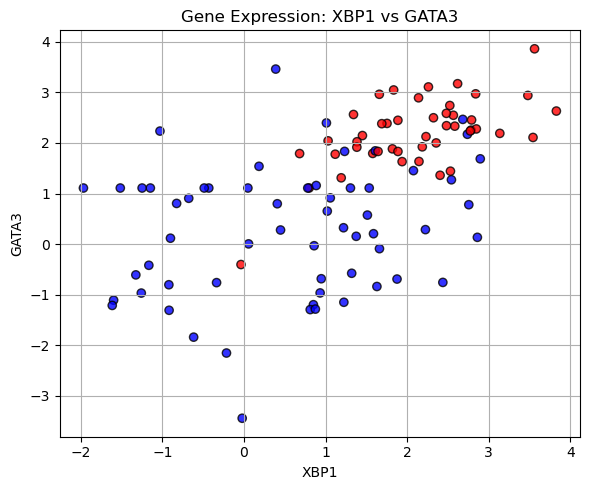

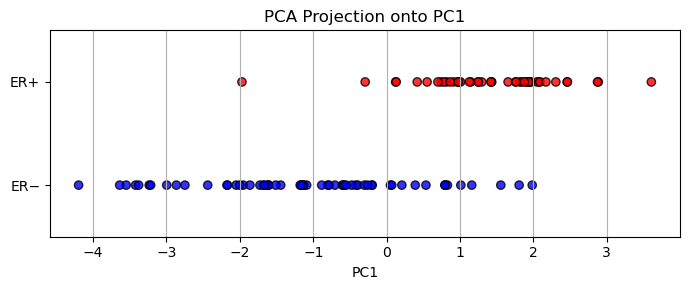

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gzip

# Step 1: Load class labels
class_labels = pd.read_csv("data/class.tsv", header=None, names=["Class"])["Class"]

# Step 2: Load gene symbol ↔ ID mapping
columns_df = pd.read_csv("data/columns.tsv.gz", sep="\t", comment="#")
gene_ids = (
    columns_df.set_index("GeneSymbol")
    .loc[["XBP1", "GATA3"], "ID"]
    .astype(str)
    .tolist()
)

# Step 3: Load filtered gene expression data
with gzip.open("data/filtered.tsv.gz", "rt") as f:
    expression_df = pd.read_csv(f, sep="\t")

expression_df.columns = expression_df.columns.str.strip()

# Step 4: Extract expression levels for XBP1 and GATA3
selected_expression = expression_df[gene_ids].copy()
selected_expression.columns = ["XBP1", "GATA3"]

# Step 5: Scatter plot (Figure 1a)
plt.figure(figsize=(6, 5))
colors = class_labels.map({1: "red", 0: "blue"})
plt.scatter(
    selected_expression["XBP1"],
    selected_expression["GATA3"],
    c=colors,
    alpha=0.8,
    edgecolor='k'
)
plt.xlabel("XBP1")
plt.ylabel("GATA3")
plt.title("Gene Expression: XBP1 vs GATA3")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: PCA projection onto PC1 (Figure 1c)
pca = PCA(n_components=1)
pc1 = pca.fit_transform(selected_expression)

# Step 7: 1D projection plot
plt.figure(figsize=(7, 3))
plt.scatter(
    pc1, class_labels,
    c=colors,
    alpha=0.8,
    edgecolor='k'
)
plt.yticks([0, 1], ["ER−", "ER+"])
plt.ylim(-0.5, 1.5)
plt.xlabel("PC1")
plt.title("PCA Projection onto PC1")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

